In [125]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

import warnings

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [126]:
def load_evidence(fn, ds_name):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    df["ds_name"] = ds_name
    ddf = df['derived'].apply(pd.Series)

    # normalize the string values for cell types
    ddf["cell_type_label"] = ddf["cell_type_label"].str.strip().str.upper()
    ddf["cell_type_id"] = ddf["cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    ddf["feature_name"] = ddf["feature_name"].str.strip().str.upper()
    ddf["feature_identifier"] = ddf["feature_identifier"].str.strip().str.upper()
    hddf = ddf.query("organism == 'homo_sapiens'").dropna(subset=["feature_identifier"])
    return hddf

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [127]:
# adipose_Hildreth2021
# adipose_Vijay2019
# adipose_Emont2022
# adipose Jaitin2019

ds1 = "adipose_Emont2022"
ds2 = "adipose_Hildreth2021"
# ds2 = "adipose_Jaitin2019"

fn_hmn1   = f"../../data/{ds1}/evidence_deg/evidence_unfiltered.json"
fn_hmn2   = f"../../data/{ds2}/evidence_deg/evidence_unfiltered.json"

ctmap_fn1 = f"../../data/{ds1}/ctmap/ctmap.json"
ctmap_fn2 = f"../../data/{ds2}/ctmap/ctmap.json"

hmn1 = load_evidence(fn_hmn1, ds1)
hmn2 = load_evidence(fn_hmn2, ds2)

ctmap1, rev_ctmap1 = get_ctmap(ctmap_fn1)
ctmap2, rev_ctmap2 = get_ctmap(ctmap_fn2)

hmn1["cell_type_id"] = hmn1["cell_type_label"].map(lambda x: rev_ctmap1[x])
hmn2["cell_type_id"] = hmn2["cell_type_label"].map(lambda x: rev_ctmap2[x])

# Global gene comparison

In [128]:
feature = "feature_identifier" # <-- to use once we fill in the id from the gene name
# feature = "feature_name"

hmn1_features = pd.Series(hmn1[feature].unique()).dropna().tolist()
hmn2_features = pd.Series(hmn2[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn1_features, hmn2_features)                # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()      # normalized counts
lv, xv, rv  = set_cmp(hmn1_features, hmn2_features, vals=True)  # actual lists

gene_vals = [l,x,r]
gene_nvals = [nl,nx,nr]

print(f"{ds1} v {ds2} ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

adipose_Emont2022 v adipose_Hildreth2021 (feature_identifier)
	left	itx	right
raw	2034	6314	2926
norm	0.18	0.56	0.26


In [129]:
# feature = "cell_type_label" # eventually change this to comparing based on a map we can create
feature = "cell_type_id"

hmn1_features = pd.Series(hmn1[feature].unique()).dropna().tolist()
hmn2_features = pd.Series(hmn2[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn1_features, hmn2_features)               # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()     # normalized counts
lv, xv, rv  = set_cmp(hmn1_features, hmn2_features, vals=True) # actual lists

ct_vals = [l,x,r]
ct_nvals = [nl,nx,nr]

print(f"{ds1} v {ds2} ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

adipose_Emont2022 v adipose_Hildreth2021 (cell_type_id)
	left	itx	right
raw	6	10	2
norm	0.33	0.56	0.11


In [130]:
# Define the multi-level column structure and data
columns = pd.MultiIndex.from_product(
    [["cell_type_id", "feature_name"], ["left", "itx", "right"]],
    names=["Feature", "Set Comparison"]
)

data = [
    ct_vals +  gene_vals,  # raw values
   ct_nvals + gene_nvals  # normalized values
]

# Create the DataFrame
df = pd.DataFrame(data, columns=columns, index=["raw", "norm"])



In [131]:
df

Feature        cell_type_id                      feature_name              \
Set Comparison         left        itx     right         left         itx   
raw                6.000000  10.000000  2.000000  2034.000000  6314.00000   
norm               0.333333   0.555556  0.111111     0.180415     0.56005   

Feature                      
Set Comparison        right  
raw             2926.000000  
norm               0.259535

# Cell-type-specific comparisons

In [132]:
def ctg_metric(df1, df2, gene_col = "feature_name", ct_col = "cell_type_label", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True):
    # common cell types
    common_ct = np.intersect1d(df1[ct_col].unique(), df2[ct_col].unique())
    common_gn = np.intersect1d(df1[gene_col].unique(), df2[gene_col].unique())


    # comm_df1 = df1[df1[ct_col].isin(common_ct)]
    # comm_df2 = df2[df2[ct_col].isin(common_ct)]
    
    # here we filter for the same set of cell types and genes <-- note we may want to change this!
    if comm_ct and not comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct)]
        comm_df2 = df2[df2[ct_col].isin(common_ct)]
    elif comm_gene and not comm_ct:
        comm_df1 = df1[df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[gene_col].isin(common_gn)]
    elif comm_ct and comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct) & df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[ct_col].isin(common_ct) & df2[gene_col].isin(common_gn)]
    else:
        comm_df1 = df1
        comm_df2 = df2

    df1_ctg_list = comm_df1.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df1_ctg_list = df1_ctg_list.reindex(common_ct, fill_value=[])
    df2_ctg_list = comm_df2.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df2_ctg_list = df2_ctg_list.reindex(common_ct, fill_value=[])

    # now take the left set diff, intersection, and right set diff for every pair of cell types in the two dataframes
    ctg_cmp = {}
    ctg_cmp_vals = {}
    for ct1 in df1_ctg_list.index:
        for ct2 in df2_ctg_list.index:
            l, x, r  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2])
            lv, xv, rv  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2], vals=True)
            ctg_cmp[(ct1, ct2)] = (l, x, r)
            ctg_cmp_vals[(ct1, ct1)] = (lv, xv, rv)

    # print(ctg_cmp)
    pvt = pd.DataFrame(ctg_cmp.values(), index=ctg_cmp.keys(), columns=["l", "x", "r"]).reset_index(names=[df1_label, df2_label]).pivot(index=df1_label, columns=df2_label, values=["l", "x", "r"]).fillna(0)

    df1_ct = pvt.index
    df2_ct = pvt.columns.levels[1]
    mtx = pvt.to_numpy().reshape(len(df1_ct), 3, len(df2_ct))
    norm_mtx = mtx / mtx.sum(axis=1)[:, np.newaxis, :]
    mtx = mtx.transpose(0,2,1)
    norm_mtx = norm_mtx.transpose(0,2,1)
    return (mtx, norm_mtx, df1_ct, df2_ct)

In [133]:
hmn1["feature_identifier"].isna().sum(), hmn2["feature_identifier"].isna().sum()

(np.int64(0), np.int64(0))

In [134]:
(mtx, norm_mtx, hmn1ct, hmn2ct) = ctg_metric(hmn1, hmn2, gene_col = "feature_identifier", ct_col = "cell_type_id", 
df1_label="hmn1", df2_label="hmn2", comm_ct=False, comm_gene=True)
df = pd.DataFrame(mtx.tolist(), index=hmn1ct, columns=hmn2ct)
df

hmn2,ADIPOCYTE,B CELL,DENDRITIC CELL,ENDOTHELIUM,INNATE LYMPHOID CELLS,MACROPHAGE,MONOCYTE,MYELOID-LIKE CELLS,NATURAL KILLER CELL,NEUTROPHIL,SMOOTH MUSCLE CELLS,T CELL
hmn1,,,,,,,,,,,,
ADIPOCYTE,"[1069, 624, 1380]","[1396, 297, 410]","[728, 965, 1154]","[1388, 305, 838]","[1181, 512, 1068]","[1007, 686, 1769]","[921, 772, 2169]","[1243, 450, 936]","[1074, 619, 1689]","[1339, 354, 832]","[1274, 419, 830]","[1120, 573, 1365]"
B CELL,"[808, 150, 1854]","[578, 380, 327]","[590, 368, 1751]","[820, 138, 1005]","[607, 351, 1229]","[617, 341, 2114]","[469, 489, 2452]","[709, 249, 1137]","[435, 523, 1785]","[781, 177, 1009]","[826, 132, 1117]","[487, 471, 1467]"
DENDRITIC CELL,"[1771, 523, 1481]","[1835, 459, 248]","[876, 1418, 701]","[1934, 360, 783]","[1587, 707, 873]","[1170, 1124, 1331]","[914, 1380, 1561]","[1389, 905, 481]","[1297, 997, 1311]","[1613, 681, 505]","[1927, 367, 882]","[1322, 972, 966]"
ENDOMETRIUM,"[193, 241, 1763]","[413, 21, 686]","[319, 115, 2004]","[360, 74, 1069]","[357, 77, 1503]","[311, 123, 2332]","[307, 127, 2814]","[386, 48, 1338]","[346, 88, 2220]","[373, 61, 1125]","[280, 154, 1095]","[360, 74, 1864]"
ENDOTHELIUM,"[896, 400, 1604]","[1174, 122, 585]","[910, 386, 1733]","[608, 688, 455]","[975, 321, 1259]","[829, 467, 1988]","[756, 540, 2401]","[1043, 253, 1133]","[868, 428, 1880]","[1080, 216, 970]","[946, 350, 899]","[983, 313, 1625]"
HUMAN ASPCS,"[243, 788, 1216]","[908, 123, 584]","[661, 370, 1749]","[871, 160, 983]","[726, 305, 1275]","[654, 377, 2078]","[689, 342, 2599]","[900, 131, 1255]","[696, 335, 1973]","[861, 170, 1016]","[755, 276, 973]","[764, 267, 1671]"
MACROPHAGE,"[1605, 794, 1210]","[2111, 288, 419]","[1289, 1110, 1009]","[1962, 437, 706]","[1900, 499, 1081]","[696, 1703, 752]","[748, 1651, 1290]","[1477, 922, 464]","[1663, 736, 1572]","[1640, 759, 427]","[1914, 485, 764]","[1721, 678, 1260]"
MAST_CELL,"[470, 161, 1843]","[533, 98, 609]","[402, 229, 1890]","[517, 114, 1029]","[386, 245, 1335]","[368, 263, 2192]","[303, 328, 2613]","[457, 174, 1212]","[351, 280, 2028]","[507, 124, 1062]","[499, 132, 1117]","[391, 240, 1698]"
MESOTHELIUM,"[380, 277, 1727]","[602, 55, 652]","[512, 145, 1974]","[529, 128, 1015]","[490, 167, 1413]","[480, 177, 2278]","[441, 216, 2725]","[579, 78, 1308]","[464, 193, 2115]","[597, 60, 1126]","[496, 161, 1088]","[519, 138, 1800]"


# Consistent cell types

In [135]:
(mtx, norm_mtx, hmn1ct, hmn2ct) = ctg_metric(hmn1, hmn2, gene_col = "feature_identifier", ct_col = "cell_type_id", 
df1_label="hmn1", df2_label="hmn2", comm_ct=True, comm_gene=True)
df = pd.DataFrame(mtx.tolist(), index=hmn1ct, columns=hmn2ct)
df.head()

hmn2,ADIPOCYTE,B CELL,DENDRITIC CELL,ENDOTHELIUM,MACROPHAGE,MONOCYTE,NATURAL KILLER CELL,NEUTROPHIL,SMOOTH MUSCLE CELLS,T CELL
hmn1,,,,,,,,,,
ADIPOCYTE,"[1069, 624, 1380]","[1396, 297, 410]","[728, 965, 1154]","[1388, 305, 838]","[1007, 686, 1769]","[921, 772, 2169]","[1074, 619, 1689]","[1339, 354, 832]","[1274, 419, 830]","[1120, 573, 1365]"
B CELL,"[808, 150, 1854]","[578, 380, 327]","[590, 368, 1751]","[820, 138, 1005]","[617, 341, 2114]","[469, 489, 2452]","[435, 523, 1785]","[781, 177, 1009]","[826, 132, 1117]","[487, 471, 1467]"
DENDRITIC CELL,"[1771, 523, 1481]","[1835, 459, 248]","[876, 1418, 701]","[1934, 360, 783]","[1170, 1124, 1331]","[914, 1380, 1561]","[1297, 997, 1311]","[1613, 681, 505]","[1927, 367, 882]","[1322, 972, 966]"
ENDOTHELIUM,"[896, 400, 1604]","[1174, 122, 585]","[910, 386, 1733]","[608, 688, 455]","[829, 467, 1988]","[756, 540, 2401]","[868, 428, 1880]","[1080, 216, 970]","[946, 350, 899]","[983, 313, 1625]"
MACROPHAGE,"[1605, 794, 1210]","[2111, 288, 419]","[1289, 1110, 1009]","[1962, 437, 706]","[696, 1703, 752]","[748, 1651, 1290]","[1663, 736, 1572]","[1640, 759, 427]","[1914, 485, 764]","[1721, 678, 1260]"


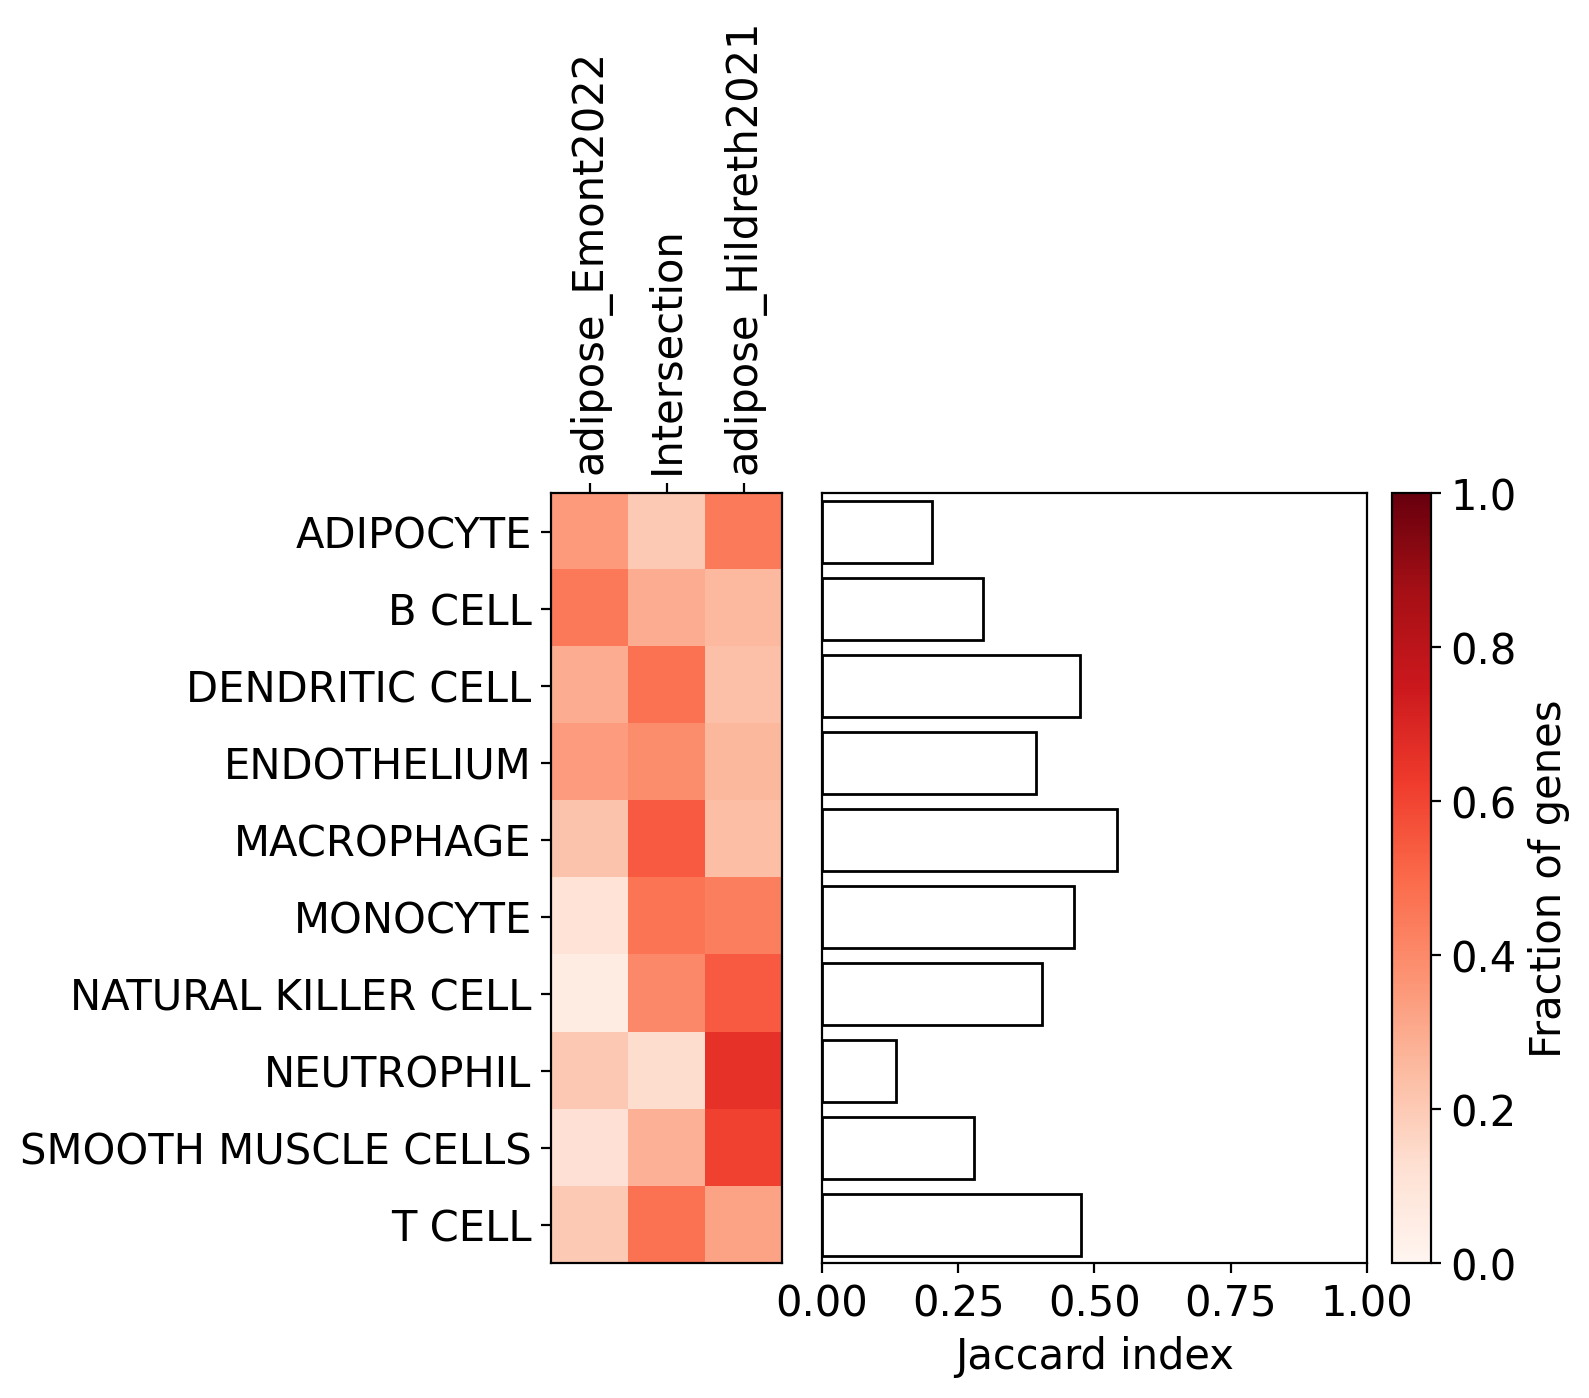

In [136]:
fig, axs = plt.subplots(figsize=(7, 5), ncols=2)
fig.subplots_adjust(hspace=0, wspace=-0.25)

ax = axs[0]
xlabels = [f"{ds1}", "Intersection", f"{ds2}"]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]

cax = ax.imshow(eye, cmap="Reds", vmin=0, vmax=1)

ax.set(**{
    "xticks": np.arange(len(xlabels)),
    "yticks": np.arange(len(hmn1ct)),
    "xticklabels": xlabels,
    "yticklabels": hmn1ct,
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')  # Set the label position at the top

ax = axs[1]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])
jac = jac[::-1]

ax.barh(np.arange(len(hmn1ct)), jac, edgecolor="black", facecolor="white")
ax.set(**{
    "yticks": np.arange(len(hmn1ct)),
    "yticklabels": [],
    "xlabel": "Jaccard index",
    # "title": "Jaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmn1ct)-0.5)
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Fraction of genes")

plt.show()


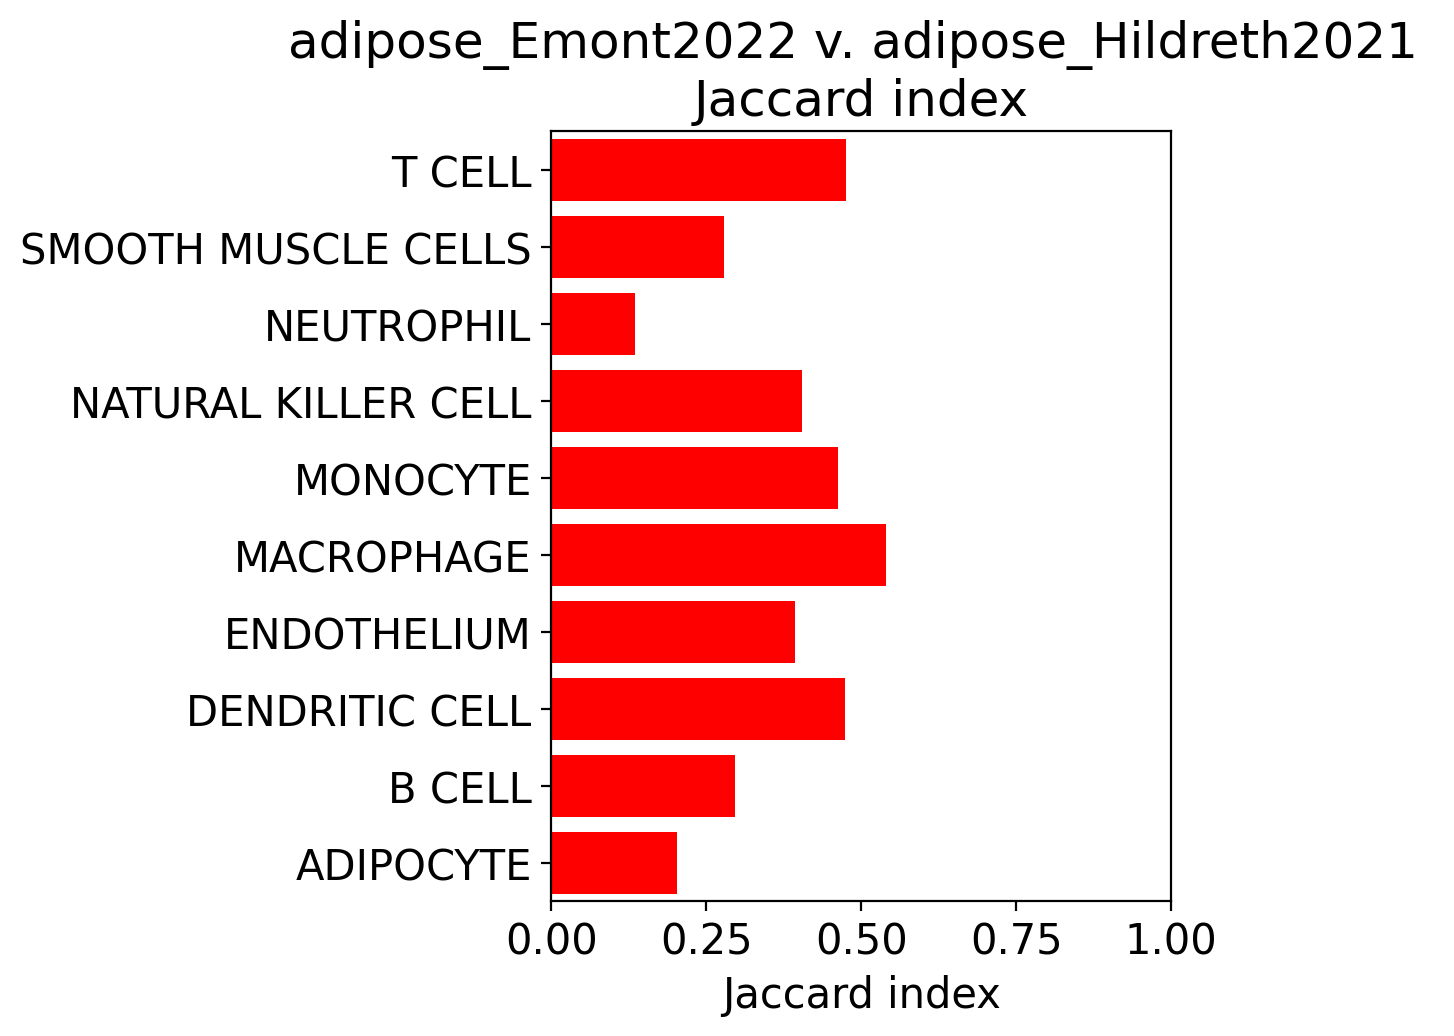

In [137]:
fig, ax = plt.subplots(figsize=(4, 5))

eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])

ax.barh(np.arange(len(hmn1ct)), jac, color="red")
ax.set(**{
    "yticks": np.arange(len(hmn1ct)),
    "yticklabels": hmn1ct,
    "xlabel": "Jaccard index",
    "title": f"{ds1} v. {ds2} \nJaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmn1ct)-0.5)
})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.show()


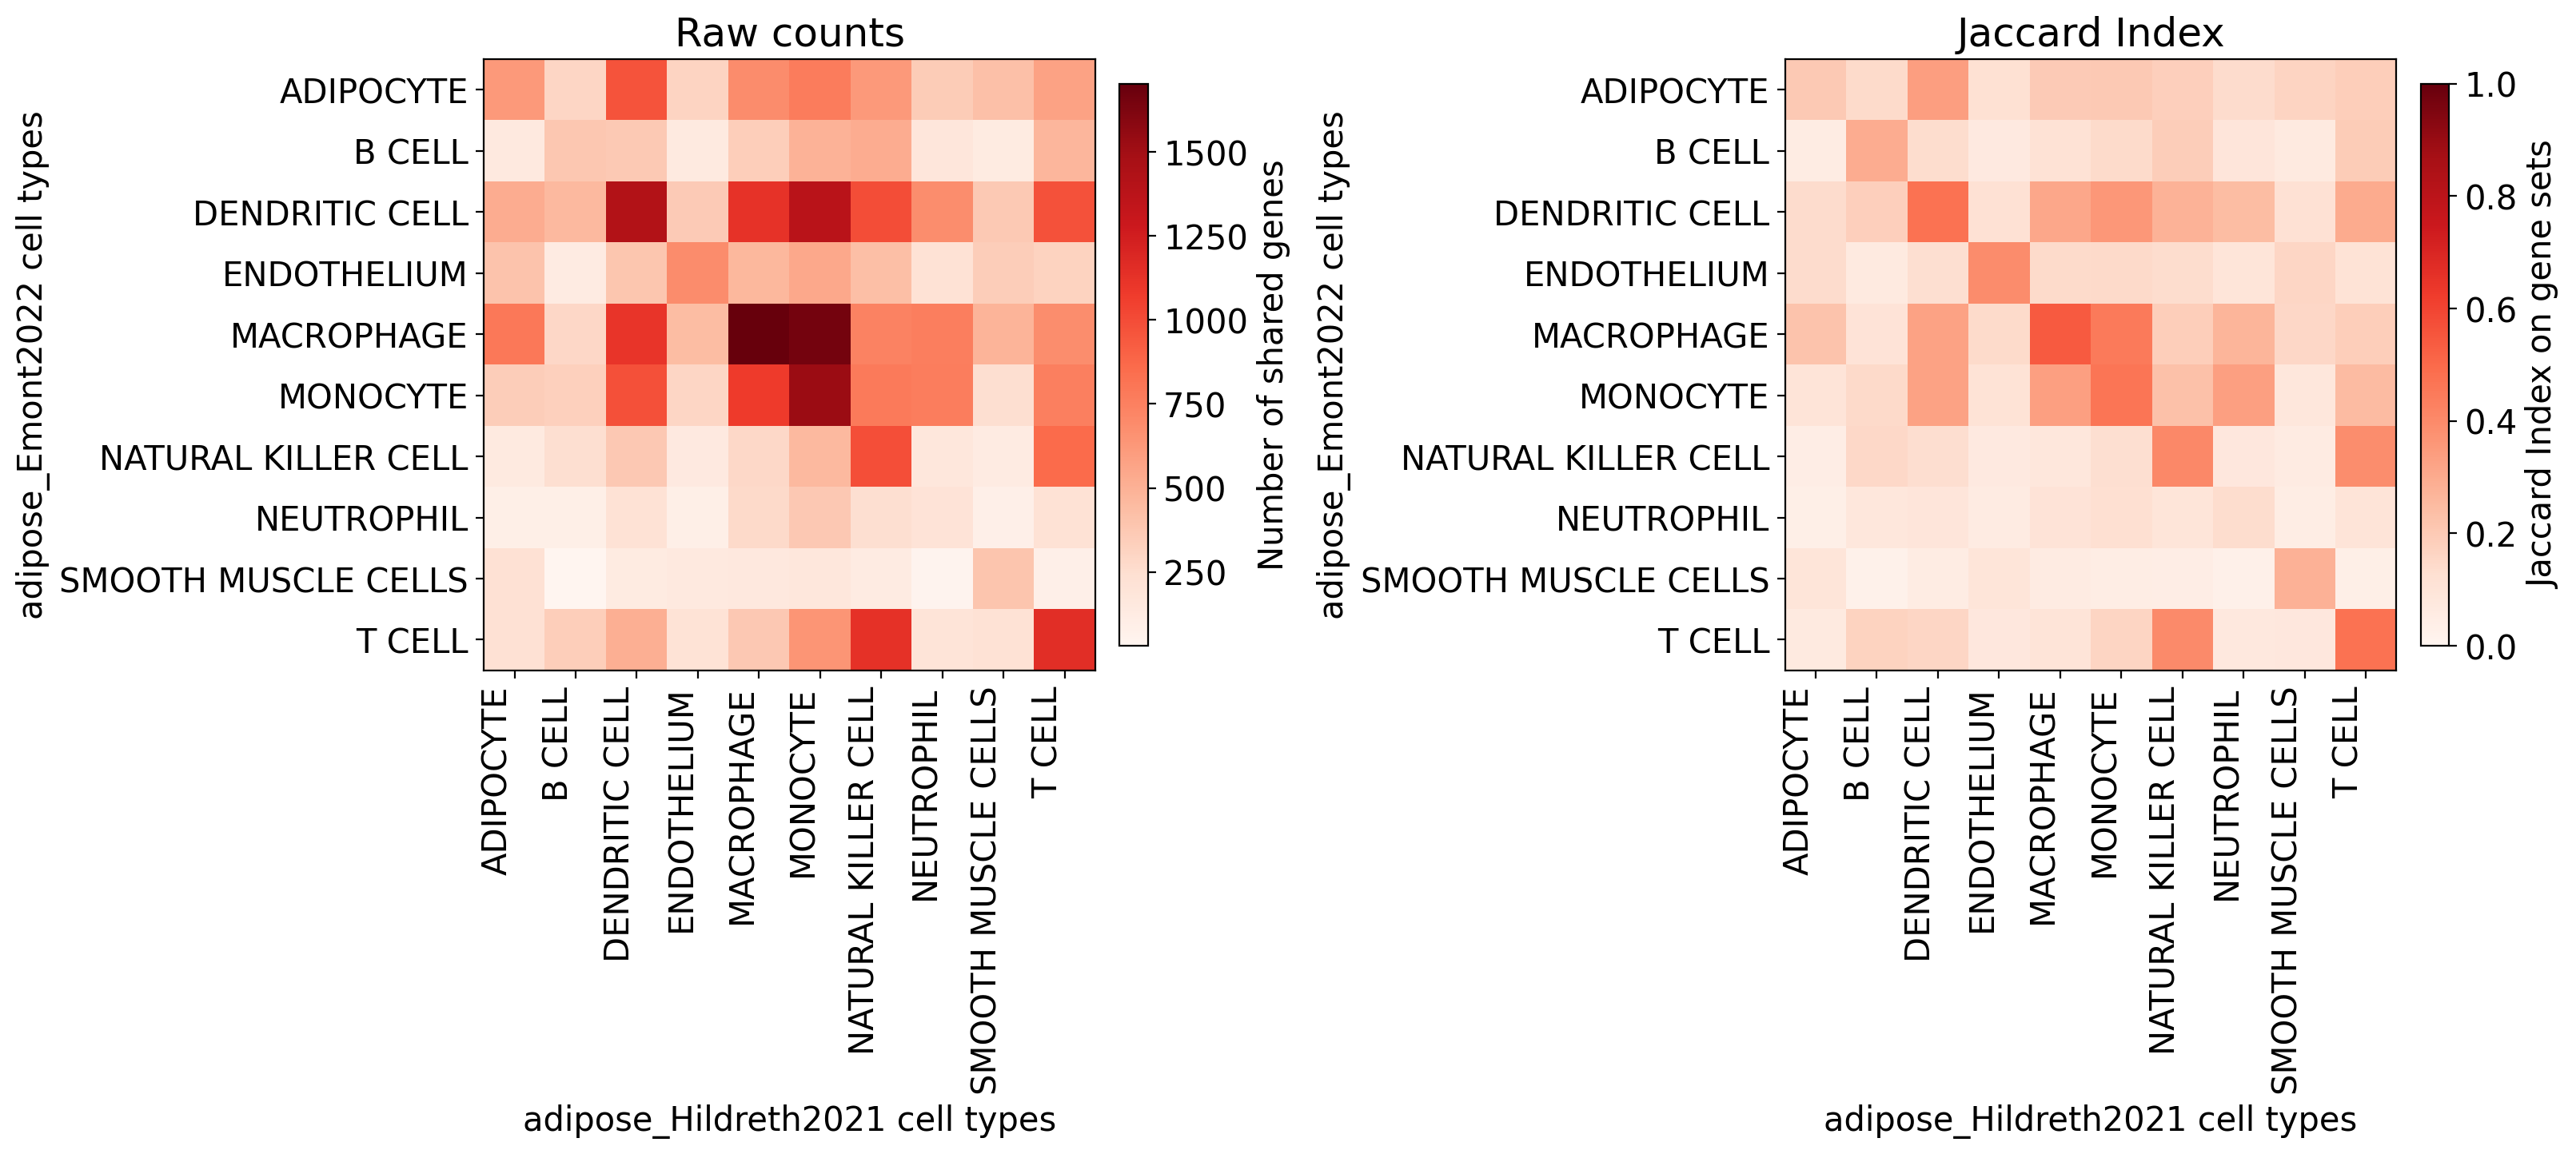

In [138]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": f"{ds2} cell types",
    "ylabel": f"{ds1} cell types",
    "xticks": np.arange(len(hmn2ct)),
    "yticks": np.arange(len(hmn1ct)),
    "xticklabels": hmn2ct,
    "yticklabels": hmn1ct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds", vmin=0, vmax=1)
ax.set(**{
    "xlabel": f"{ds2} cell types",
    "ylabel": f"{ds1} cell types",
    "xticks": np.arange(len(hmn2ct)),
    "yticks": np.arange(len(hmn1ct)),
    "xticklabels": hmn2ct,
    "yticklabels": hmn1ct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


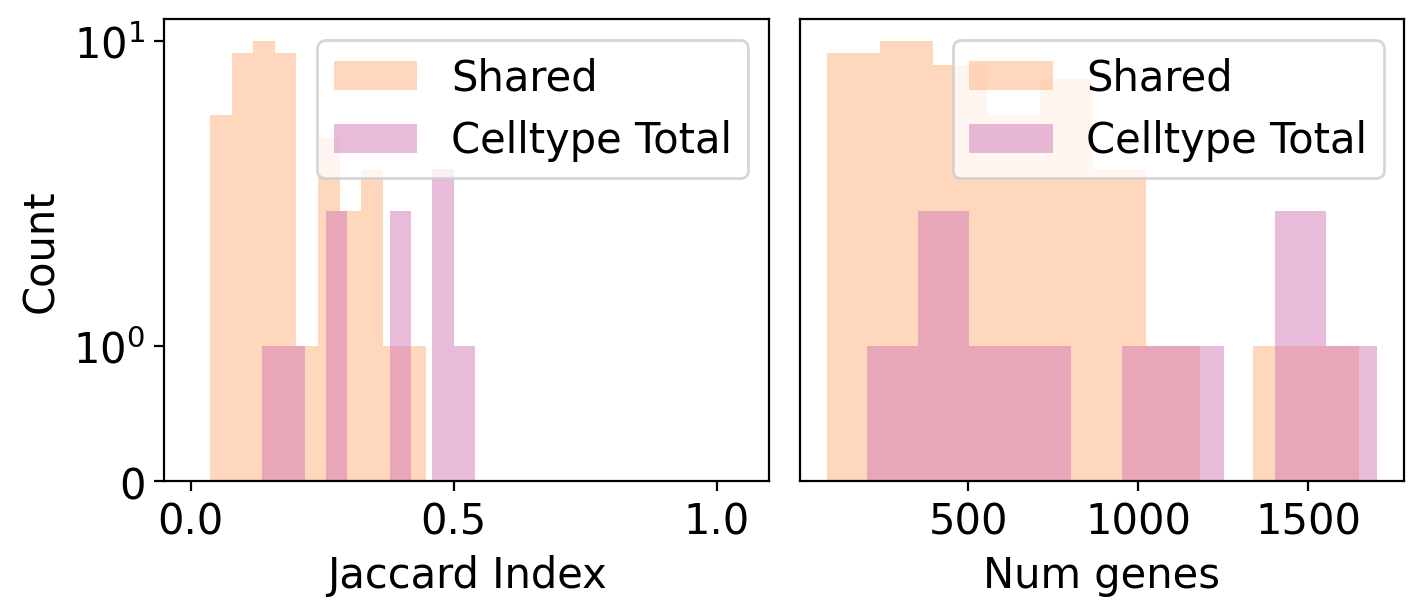

In [139]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

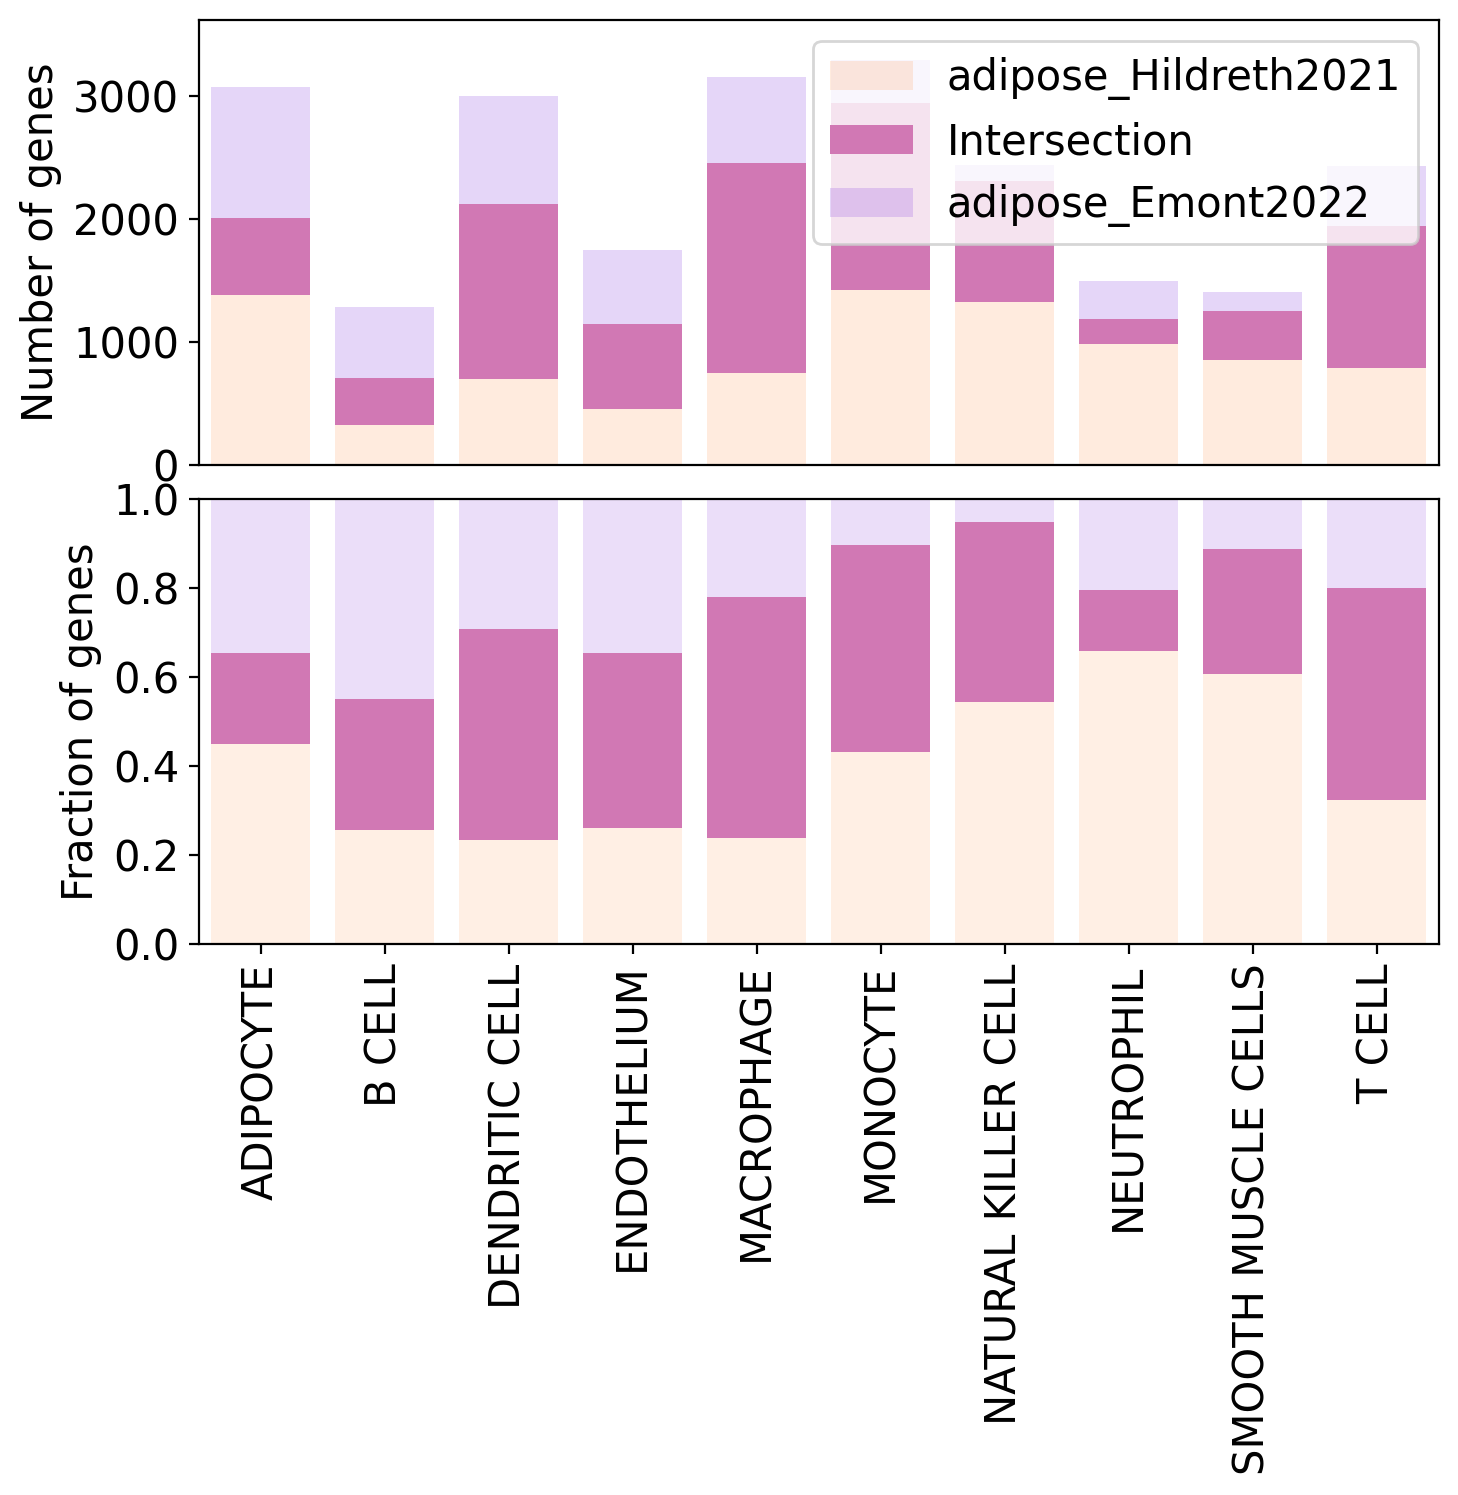

In [140]:
fig, axs = plt.subplots(figsize=(8,6), nrows=2)
fig.subplots_adjust(hspace=0.075, wspace=0.5)
ax = axs[0]
y3 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y1 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmn1ct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.25, label=f'{ds2}')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.25, label=f'{ds1}')

ax.set(
    **{
        "ylabel": "Number of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max()),
        "xlim": (-0.5, len(x)-0.5)
    }
)
ax.xaxis.set_visible(False)

# ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend()#bbox_to_anchor=(1,1))

ax = axs[1]
ax.sharex(axs[0])
y3 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y1 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmn1ct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'{ds2}')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'{ds1}')

ax.set(
    **{
        "ylabel": "Fraction of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1),
        "xlim": (-0.5, len(x)-0.5)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()
